In [1]:
!pip install mlxtend varclushi

In [2]:
import pandas as pd
import mlxtend.preprocessing as mlx_preprocessing
import mlxtend.frequent_patterns as mlx_freq
import networkx as nx
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


***TASK 1***

*Загрузите файл «assc_TRANSACTION.csv». В нем три колонки Customer – ID клиента, Product – 
покупка, Time – временная метка (для задания не нужна). Определите (написав 
соответствующий код) сколько различных значений принимают переменные Product и 
Customer.*

In [3]:
df = pd.read_csv("TRANSACTION.csv")
cust_count = len(df['CUSTOMER'].unique())
prod_count = len(df['PRODUCT'].unique())
print(f"customer: {cust_count}, product:{prod_count}")

customer: 1001, product:20


***TASK 2***

*Найдите частые эпизоды с ограничением на размер правила равным 4, с использованием алгоритма и порога на поддержку*

In [4]:
group_CS = df.groupby("CUSTOMER").aggregate({"PRODUCT":list}).values[:,0]
te = mlx_preprocessing.TransactionEncoder()
te_ary = te.fit_transform(group_CS)
transaction_df = pd.DataFrame(te_ary, columns=te.columns_)
freq_itemsets = mlx_freq.fpgrowth(transaction_df,min_support=0.03,use_colnames=True,max_len=4)
task_2 = freq_itemsets.loc[freq_itemsets['itemsets'].apply(lambda x: len(x) <= 4)]
task_2

,support,itemsets
0,0.485514,frozenset({hering})
1,0.472527,frozenset({olives})
2,0.402597,frozenset({bourbon})
3,0.390609,frozenset({corned_b})
4,0.312687,frozenset({ice_crea})
...,...,...
656,0.032967,"frozenset({chicken, soda, bourbon, cracker})"
657,0.031968,"frozenset({hering, bordeaux})"
658,0.031968,"frozenset({bordeaux, cracker})"
659,0.043956,"frozenset({bordeaux, heineken})"


***TASK 3***

*Найдите самый большой (где больше всего элементов) частый эпизод, содержащий продукт 'coke'. Какая у него поддержка?*

In [5]:
task_3 = freq_itemsets.loc[freq_itemsets['itemsets'].apply(lambda x: 'coke' in x and len(x) == 4),'support']
print(task_3)

194    0.094905
195    0.095904
196    0.094905
389    0.116883
393    0.115884
394    0.115884
415    0.030969
423    0.035964
441    0.034965
445    0.096903
446    0.039960
454    0.115884
Name: support, dtype: float64


***TASK 4***

*На основе найденных частых эпизодов постройте ассоциативные правила с порогом на 
достоверность. Найдите правило с максимальным лифтом, содержащем продукт 'coke' в левой части правила. Дайте ему письменную словесную интерпретацию, укажите и объясните его числовые показатели: поддержку, достоверность и подъем.*

In [6]:
rules = mlx_freq.association_rules(freq_itemsets, metric="confidence", min_threshold=0.2)
rules_with_PR = rules[rules['antecedents'].apply(lambda x: 'coke' in x)]
rules_filtered = rules_with_PR[(rules_with_PR['antecedents'].apply(len) <= 2) & (rules_with_PR['consequents'].apply(len) <= 2)]
max_lift = rules_filtered.sort_values('lift', ascending=False).iloc[0]
max_lift

antecedents              frozenset({coke, sardines})
consequents           frozenset({ice_crea, chicken})
antecedent support                          0.146853
consequent support                           0.13986
support                                     0.115884
confidence                                  0.789116
lift                                        5.642177
representativity                                 1.0
leverage                                    0.095345
conviction                                  4.078728
zhangs_metric                               0.964387
jaccard                                     0.678363
certainty                                   0.754826
kulczynski                                  0.808844
Name: 1516, dtype: object

**Числовые показатели:**

*Поддержка (support): 0.11588 или около 11.6%*

*Достоверность (confidence): 0.78912 или около 78.9%*

*Подъем (lift): 5.64218 или около 5.64*

**Интерпретация:**

*Это правило показывает, что когда покупатели приобретают кока-колу и сардины вместе, то в 78.9% случаев они также покупают мороженое и курицу.
Значение поддержки 11.6% говорит о том, что примерно в 11.6% всех транзакций наблюдается совместная покупка всех четырех товаров: кока-колы, сардин, мороженого и курицы. Это указывает на то, что такая комбинация покупок встречается достаточно часто для выявления значимой закономерности*

***TASK 5***

*Используя только двухместные правила постройте ориентированный граф, где вершины 
элементы правила, их цвет (или размер) – поддержка элемента (item support), дуги – 
импликации (ориентированы в направлении от условия к следствию), веса дугu – 
достоверности.*

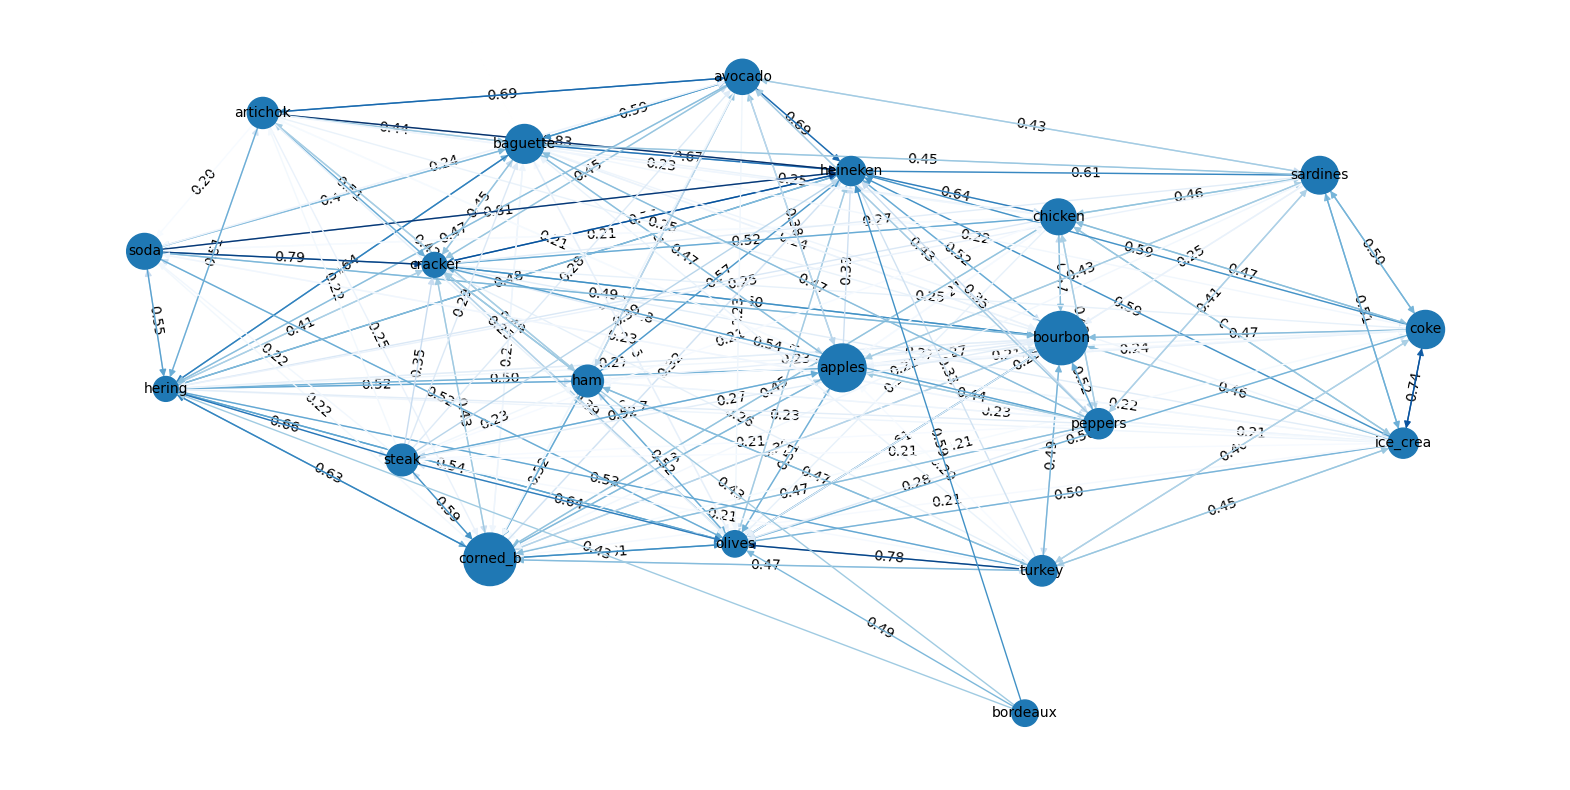

In [7]:
G = nx.DiGraph()

task_5 = rules.loc[(rules['antecedents'].apply(len) == 1) & (rules['consequents'].apply(len) == 1)]


for index,row in task_5.iterrows():
    for item in row['antecedents']:
        G.add_node(item,support=row['support'])
    for item in row['consequents']:
        G.add_node(item,support=row['support'])

for index,row in task_5.iterrows():
    for antecedent in row['antecedents']:
        for consequent in row['consequents']:
            G.add_edge(antecedent, consequent, weight=row['confidence'])

pos = nx.spring_layout(G)  # Расположение узлов
sizes = [G.nodes[n]['support'] * 10000 for n in G.nodes]
edges = G.edges(data=True) 
weights = [d['weight'] * 100 for (u, v, d) in edges]  # Вес дуг


# for u,v,d in edges:
#     print(d)
plt.figure(figsize=(20,10))

edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

nx.draw(G, pos, with_labels=True, node_size=sizes, edge_color=weights, edge_cmap=plt.cm.Blues, font_size=10)

***TASK 6***

*Для данного графа рассчитайте меры центральности и найдите элемент с самой высокой мерой, а также какую меру имеет продукт 'coke' .*

<BarContainer object of 20 artists>

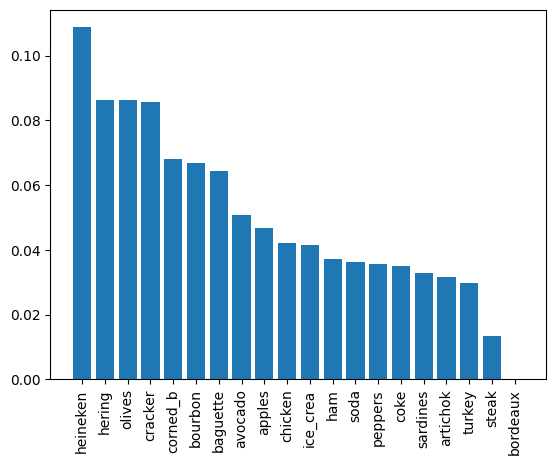

In [8]:
hubs, authorities = nx.hits(G) #Authority
max_authority = max(authorities, key=authorities.get)
authorities_sort = dict(sorted(authorities.items(), key=lambda x: x[1], reverse=True))
plt.xticks(rotation='vertical')
plt.bar(authorities_sort.keys(), authorities_sort.values())

***TASK 7***

*Постройте числовую матрицу со счетчиком числа покупок в ячейках, клиентами по строкам и 
продуктами по столбцам.*

In [9]:
purchase_matrix = df.pivot_table(index='CUSTOMER', columns='PRODUCT', aggfunc='size', fill_value=0)
purchase_matrix

PRODUCT,apples,artichok,avocado,baguette,bordeaux,bourbon,chicken,coke,corned_b,cracker,ham,heineken,hering,ice_crea,olives,peppers,sardines,soda,steak,turkey
CUSTOMER,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,1,0,0,1,0,1,0,1,1,1,0,0,0,0,1
1,0,0,0,1,0,0,0,0,1,1,0,1,1,0,1,0,0,1,0,0
2,0,1,1,0,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,1
3,0,0,0,0,0,1,0,1,0,0,1,0,0,1,1,1,0,0,0,1
4,1,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,0,1,1,0,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0
997,1,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,0,0,0,1
998,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,2,1,0,0


***TASK 8***

*С помощью метода NMF постройте линейную проекцию набора данных на плоскость (2 компоненты) цветом укажите транзакции, содержащие продукт 'coke'*

Оптимальное число компонент NMF: 10


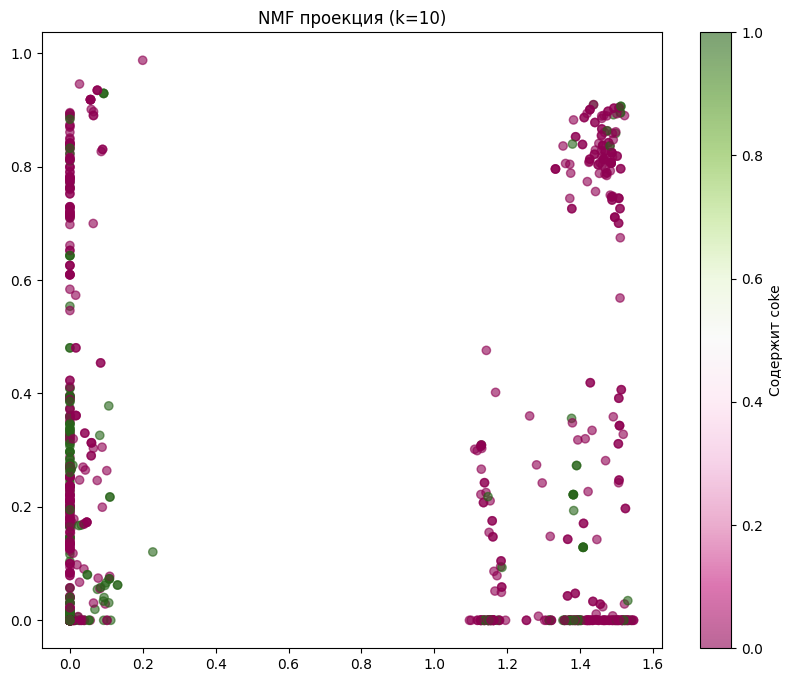

In [11]:
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(purchase_matrix.values)

errors = []
for k in range(2, 11):
    model = NMF(n_components=k, init='random', random_state=42, max_iter=500)
    W = model.fit_transform(X_scaled)
    X_recon = model.inverse_transform(W)
    mse = ((X_scaled - X_recon) ** 2).mean()
    errors.append((k, mse))

best_k = min(errors, key=lambda x: x[1])[0]
print(f"Оптимальное число компонент NMF: {best_k}")

model = NMF(n_components=best_k, init='random', random_state=42, max_iter=500)
W = model.fit_transform(X_scaled)
H = model.components_

W_2d = W[:, :2]

has_product = purchase_matrix.iloc[:, 7] > 0

plt.figure(figsize=(10, 8))
plt.scatter(W_2d[:, 0], W_2d[:, 1], c=has_product, cmap="PiYG", alpha=0.6)
plt.colorbar(label='Содержит coke')
plt.title(f'NMF проекция')
plt.show()

NMF:
Оптимизирует факторизацию V ≈ WH с ограничением неотрицательности
Использует мультипликативные правила обновления или другие алгоритмы оптимизации
Минимизирует обычно квадратичную ошибку или дивергенцию KL

PCA:
Основан на разложении ковариационной матрицы и нахождении собственных векторов и собственных значений
Компоненты выбираются в направлении максимальной дисперсии данных
Является оптимальным с точки зрения минимизации ошибки реконструкции

NMF хорош, когда:
Вам нужны понятные "темы" или "группы"
Отрицательные значения не имеют смысла (количество покупок, просмотров)
Важнее интерпретация, чем точность

PCA хорош, когда:
Нужно максимально сжать информацию
Отрицательные значения имеют смысл (например, отклонения от среднего)
Важнее математическая оптимальность

**Образно говоря, NMF ищет ингредиенты рецептов, а PCA ищет главные направления, вдоль которых данные больше всего "растянуты".**

***TASK 9***

*С помощью метода tSNE постройте нелинейную проекцию набора данных на плоскость цветом укажите транзакции, содержащие продукт 'coke' . Не указанные в задании параметры (например, размер решетки для SOM или число слоев в автоэнкодере можно выбирать на свое усмотрение для получение наиболее удобной визуализации). Дайте письменный комментарий, чем с вашей точки зрения для вашего примера лучше или хуже нелинейная проекция.*

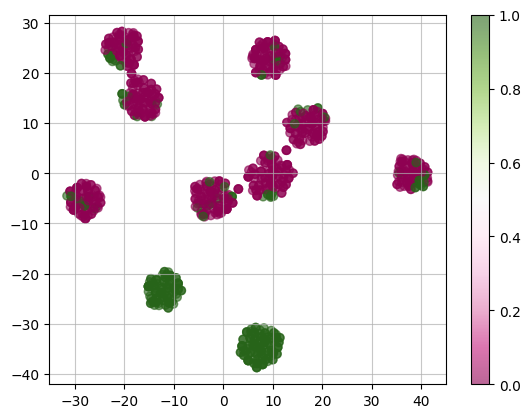

In [13]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


best_score = -1
best_embedding = None
best_params = {}
for perp in [5, 30, 50]:
    for lr in ['auto', 200, 500]:
        tsne = TSNE(n_components=2, init='random', perplexity=perp, 
                    learning_rate=lr, random_state=42, max_iter=1000)
        embedded = tsne.fit_transform(binary_df)
        sil = silhouette_score(embedded, has_product)
        if sil > best_score:
            best_score = sil
            best_embedding = embedded
            best_params = {'perplexity': perp, 'learning_rate': lr}

kmeans = KMeans(n_clusters=10, random_state=42, n_init=5)
kmeans_labels = kmeans.fit_predict(binary_df)

plt.scatter(best_embedding[:,0], best_embedding[:,1], c=has_product, cmap='PiYG', alpha=0.6)
plt.grid(True, linestyle='-', alpha=0.7)
plt.colorbar()

*Нелинейная проекция с использованием tSNE нам нужна чтобы отобразить нелинейные зависимости данных. Допустим, нам надо разделить данные на кластеры, при линейной проекции мы не сможем это сделать также хорошо, как при нелинейной. В моем случае нелинейная проекция с использованием TSNE отображает похожие транзакции, что в дальнейшем поможет правильно проводить анализ покупок.*

In [ ]:
# repr_products = VarClusHi(purchase_matrix,maxeigval2=1,maxclus=10)
# repr_products.varclus()
# repr_products.rsquare.loc[repr_products.rsquare.groupby('Cluster')['RS_Ratio'].values]
# repr_products.rsquare
# for cluster_id in np.unique(kmeans_labels):
#     cluster_name = f'Cluster{cluster_id}'  # Формат имени кластера должен соответствовать вашему
#     top_vars = vc.rsquare.loc[vc.rsquare.groupby('Cluster')['RS_Ratio'].idxmax()].head(3)
#     representative_products[cluster_id] = top_vars.index.tolist()

***TASK 10***

*Из исходной матрицы (из пункта 7) отберите указанное число независимых переменных с использованием заданного метода Varclus*

In [20]:
from varclushi import VarClusHi

best_clus = None
best_rs_ratio = 0
for n_clus in range(2, 8):
    vc = VarClusHi(purchase_matrix, maxeigval2=1, maxclus=4)
    vc.varclus()
    avg_rs = vc.rsquare['RS_Ratio'].mean()
    if avg_rs > best_rs_ratio:
        best_rs_ratio = avg_rs
        best_clus = n_clus

representatives = vc.rsquare.loc[vc.rsquare.groupby('Cluster')['RS_Ratio'].idxmin()]
representatives[['Variable', 'RS_Ratio']]

,Variable,RS_Ratio
1,avocado,0.466617
6,coke,0.450483
12,heineken,0.404158
17,hering,0.557592
